In [12]:
2+2

4

In [13]:
%pip install ipykernel pandas numpy matplotlib pillow

Note: you may need to restart the kernel to use updated packages.


In [14]:
# Cell 1: imports
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.collections import LineCollection

plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 130
plt.rcParams["font.size"] = 10

In [29]:
# Cell 2: paths and settings

BASE = Path(r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients")
MODEL_PATH = BASE / "florida_model_df.parquet"

# Use percent units for the threshold. None means no filtering.
COVERAGE_THRESHOLD_PCT = 30.0 # this should be 0.3
USE_INTERPOLATION = True # 
SMOOTH_WINDOW = None   # e.g. 3, 6, 12, or None
MAX_WINDOWS_TO_PLOT = 20 # try decreasing this substantially if the gif bit takes too long or the file is too large.
MAX_X_HOURS_CAP = 12 * 24   # cap if needed; actual x-limit is longest selected window, clipped to this
WIND_KIND = "gust_mps"      # "gust_mps", "wind_speed_mps", or None
ANIM_HOUR_STEP = 3          # show every 3rd hour
ANIM_INTERVAL_MS = 60       # faster playback

In [30]:
# Cell 3: load data

df = pd.read_parquet(MODEL_PATH).copy()

for col in ["datetime", "event_start"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

if "CountyFIPS" not in df.columns:
    raise ValueError("CountyFIPS is missing, but you said it is definitely present.")

needed = [
    "event_id", "storm", "CountyFIPS", "county", "datetime", "event_start",
    "duration_hours", "gust_mps", "wind_speed_mps", "precip_mm",
    "pressure_hpa", "temp_c", "outageFraction", "customersTracked"
]
keep = [c for c in needed if c in df.columns]
df = df[keep].copy()

df["CountyFIPS"] = df["CountyFIPS"].astype("string")
df["window_id"] = df["event_id"].astype("string") + "__" + df["CountyFIPS"].astype("string")
df = df.sort_values(["event_start", "event_id", "CountyFIPS", "datetime"]).reset_index(drop=True)

df["rel_hour"] = ((df["datetime"] - df["event_start"]).dt.total_seconds() / 3600.0).round().astype("Int64")
df = df[df["rel_hour"].notna() & (df["rel_hour"] >= 0)].copy()

print(df[["event_id", "CountyFIPS", "county"]].drop_duplicates().shape)
print(df["window_id"].nunique())

(99, 3)
99


In [31]:
# Cell 4: helpers

def coverage_threshold_to_raw_units(series, threshold_pct):
    s = pd.to_numeric(series, errors="coerce")
    finite = s.dropna()
    if len(finite) == 0:
        return threshold_pct
    # If stored as fraction, convert 30 -> 0.30. If stored as percent, keep 30.
    return threshold_pct / 100.0 if finite.max() <= 1.5 else threshold_pct

def choose_windows(df, max_windows=40, window_ids=None):
    meta = (
        df[["window_id", "event_start", "storm", "event_id", "CountyFIPS", "county"]]
        .drop_duplicates("window_id")
        .sort_values(["event_start", "storm", "CountyFIPS"])
        .reset_index(drop=True)
    )
    if window_ids is not None:
        window_ids = set(window_ids)
        meta = meta[meta["window_id"].isin(window_ids)].copy()

    if len(meta) > max_windows:
        idx = np.linspace(0, len(meta) - 1, max_windows).round().astype(int)
        meta = meta.iloc[idx].copy()

    keep = meta["window_id"].tolist()
    sub = df[df["window_id"].isin(keep)].copy()
    rank = {wid: i for i, wid in enumerate(meta["window_id"].tolist())}
    sub["window_rank"] = sub["window_id"].map(rank)
    return sub, meta

def make_hourly_series(
    g,
    value_col,
    threshold_pct=None,
    interpolate_missing=False,
    smooth_window=None,
    x_cap_hours=None,
    convert_to_kmh=False,
):
    g = g.sort_values("datetime").copy()
    max_hour = int(g["rel_hour"].max())
    if x_cap_hours is not None:
        max_hour = min(max_hour, int(x_cap_hours))
    hours = pd.RangeIndex(0, max_hour + 1, name="hour")

    if threshold_pct is None:
        src = g
    else:
        thr_raw = coverage_threshold_to_raw_units(g["customersTracked"], threshold_pct)
        src = g[pd.to_numeric(g["customersTracked"], errors="coerce") >= thr_raw].copy()

    hourly = src.groupby("rel_hour")[value_col].mean().reindex(hours)

    if convert_to_kmh and hourly.notna().any():
        hourly = hourly * 3.6

    raw = hourly.copy()
    series = raw.copy()

    if interpolate_missing:
        series = series.interpolate(method="linear", limit_area="inside")

    if smooth_window is not None and smooth_window > 1:
        series = series.rolling(smooth_window, min_periods=1, center=True).mean()

    out = pd.DataFrame({"hour": hours, "raw": raw, "value": series})
    out["interpolated"] = out["raw"].isna() & out["value"].notna()
    return out

def split_segments(x, y, interpolated_mask):
    x = np.asarray(x)
    y = np.asarray(y)
    im = np.asarray(interpolated_mask, dtype=bool)

    solid, dashed = [], []
    for i in range(len(x) - 1):
        if np.any(np.isnan([x[i], x[i + 1], y[i], y[i + 1]])):
            continue
        seg = [(x[i], y[i]), (x[i + 1], y[i + 1])]
        if im[i] or im[i + 1]:
            dashed.append(seg)
        else:
            solid.append(seg)
    return solid, dashed

def add_piecewise_line(ax, x, y, interpolated_mask, color, lw=1.5, alpha=0.95, zorder=2):
    solid, dashed = split_segments(x, y, interpolated_mask)
    if solid:
        ax.add_collection(LineCollection(solid, colors=[color], linewidths=lw, alpha=alpha, zorder=zorder))
    if dashed:
        ax.add_collection(
            LineCollection(
                dashed,
                colors=[color],
                linewidths=lw,
                linestyles="dashed",
                alpha=alpha,
                zorder=zorder,
            )
        )

def plot_overlay(
    df,
    value_col="outageFraction",
    wind_kind=None,                  # None, "gust_mps", or "wind_speed_mps"
    threshold_pct=COVERAGE_THRESHOLD_PCT,
    interpolate_missing=False,
    smooth_window=None,
    max_windows=MAX_WINDOWS_TO_PLOT,
    x_cap_hours=MAX_X_HOURS_CAP,
    window_ids=None,
    title=None,
    outfile=None,
):
    sub, meta = choose_windows(df, max_windows=max_windows, window_ids=window_ids)

    # x-axis is based on the longest selected window, clipped by the cap
    longest = int(sub.groupby("window_id")["rel_hour"].max().max())
    x_max = min(longest, x_cap_hours)

    outage_cmap = mpl.cm.Oranges
    wind_cmap = mpl.cm.Blues

    outage_series = []
    wind_series = []

    for wid, g in sub.groupby("window_id", sort=False):
        s = make_hourly_series(
            g,
            value_col=value_col,
            threshold_pct=threshold_pct,
            interpolate_missing=interpolate_missing,
            smooth_window=smooth_window,
            x_cap_hours=x_max,
            convert_to_kmh=False,
        )
        s["window_id"] = wid
        s["window_rank"] = g["window_rank"].iloc[0]
        outage_series.append(s)

        if wind_kind is not None and wind_kind in g.columns:
            w = make_hourly_series(
                g,
                value_col=wind_kind,
                threshold_pct=None,          # do not filter the wind itself
                interpolate_missing=interpolate_missing,
                smooth_window=smooth_window,
                x_cap_hours=x_max,
                convert_to_kmh=True,         # m/s -> km/h
            )
            w["window_id"] = wid
            w["window_rank"] = g["window_rank"].iloc[0]
            wind_series.append(w)

    if not outage_series:
        raise ValueError("No windows remain after filtering.")

    outage_series = sorted(outage_series, key=lambda d: d["window_rank"].iloc[0])
    wind_series = sorted(wind_series, key=lambda d: d["window_rank"].iloc[0]) if wind_series else []

    n = len(outage_series)
    shades_out = np.linspace(0.80, 0.25, n)   # later windows darker
    shades_wind = np.linspace(0.80, 0.25, max(len(wind_series), 1))

    if wind_kind is None:
        fig, ax0 = plt.subplots(figsize=(12, 5.5))
        ax1 = None
    else:
        fig, (ax0, ax1) = plt.subplots(
            2, 1, figsize=(12, 8), sharex=True,
            gridspec_kw={"height_ratios": [2, 1], "hspace": 0.08}
        )

    for i, s in enumerate(outage_series):
        color = outage_cmap(shades_out[i])
        add_piecewise_line(
            ax0,
            s["hour"].to_numpy(),
            s["value"].to_numpy(),
            s["interpolated"].to_numpy(),
            color=color,
            lw=1.6,
            zorder=1 + i,
        )

    ax0.set_xlim(0, x_max)
    ax0.set_ylim(0, 1.0)
    ax0.set_ylabel("outageFraction")
    ax0.grid(True, alpha=0.25)
    ax0.set_title(title or "Outage trajectories")

    if ax1 is not None:
        wind_max = 0.0
        for i, s in enumerate(wind_series):
            color = wind_cmap(shades_wind[i])
            vals = s["value"].dropna()
            if len(vals):
                wind_max = max(wind_max, float(vals.max()))
            add_piecewise_line(
                ax1,
                s["hour"].to_numpy(),
                s["value"].to_numpy(),
                s["interpolated"].to_numpy(),
                color=color,
                lw=1.4,
                zorder=1 + i,
            )
        ax1.set_xlim(0, x_max)
        ax1.set_ylim(0, wind_max * 1.05 if wind_max > 0 else 1.0)
        ax1.set_ylabel(f"{wind_kind} (km/h)")
        ax1.set_xlabel("Hours since event start")
        ax1.grid(True, alpha=0.25)
    else:
        ax0.set_xlabel("Hours since event start")

    fig.tight_layout()
    if outfile is not None:
        fig.savefig(outfile, bbox_inches="tight")
    return fig, meta

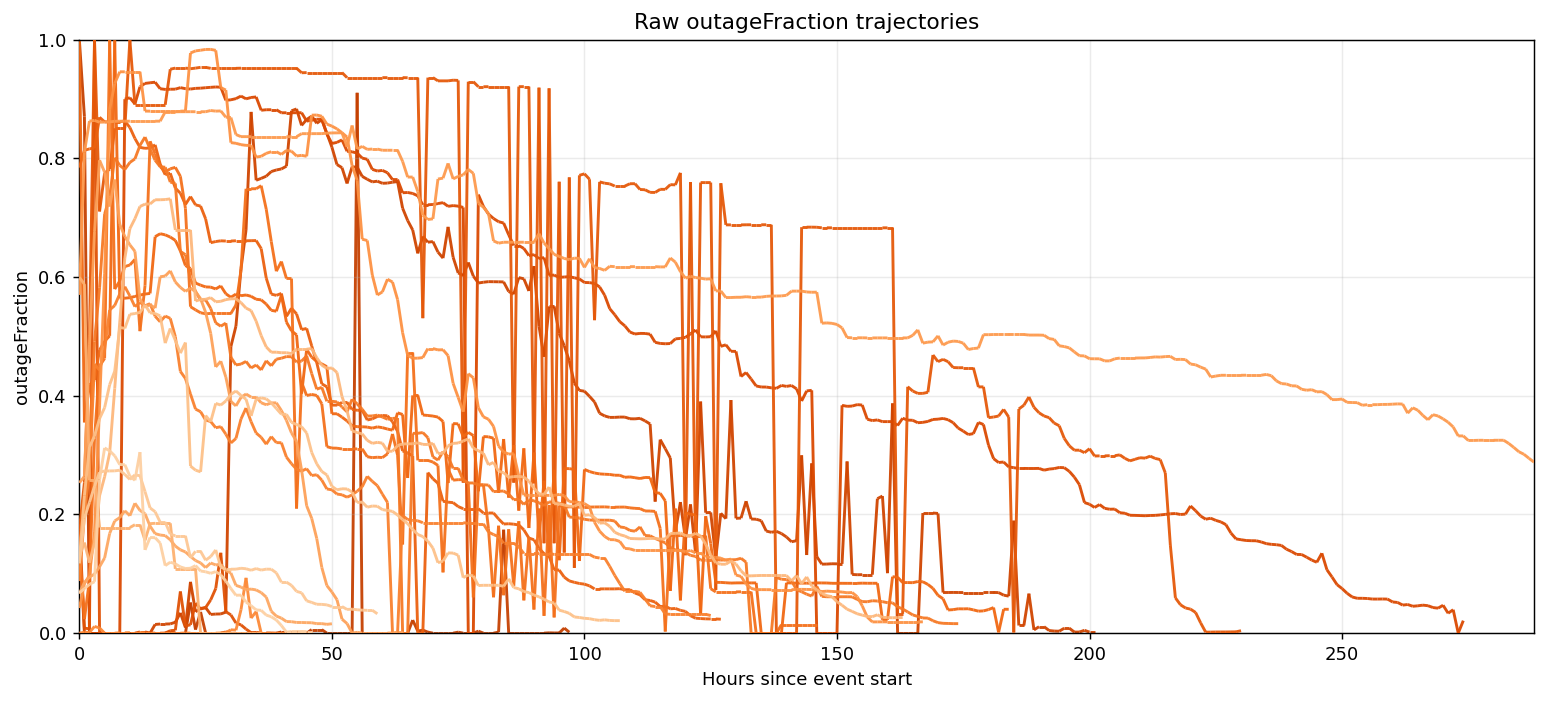

In [26]:
# Cell 5: raw outage only
fig, meta = plot_overlay(
    df,
    value_col="outageFraction",
    wind_kind=None,
    threshold_pct=None,              # no filtering
    interpolate_missing=False,
    smooth_window=None,
    max_windows=MAX_WINDOWS_TO_PLOT,
    title="Raw outageFraction trajectories",
    outfile=BASE / "raw_outage_overlay.png",
)
plt.show()

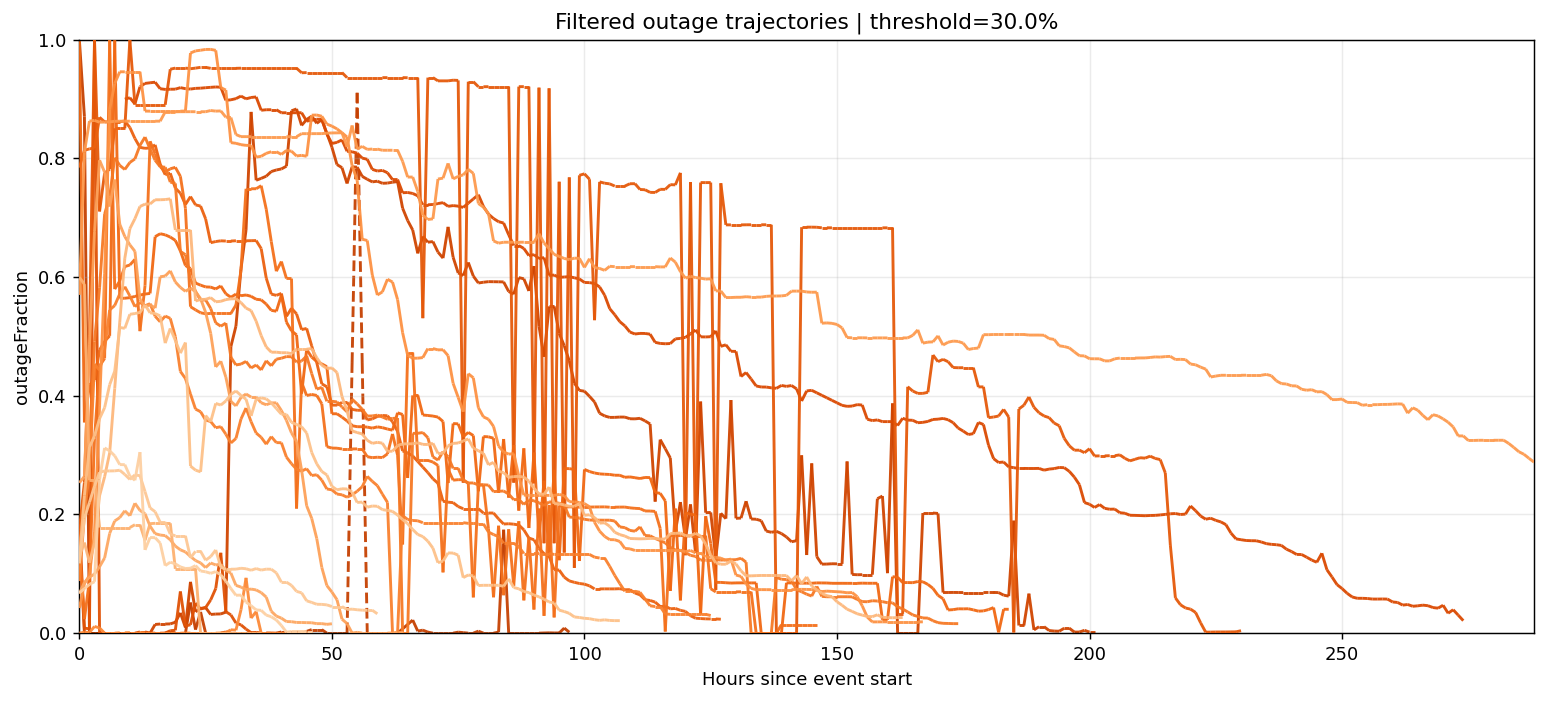

In [27]:
# Cell 6: filtered outage with optional interpolation and smoothing
fig, meta = plot_overlay(
    df,
    value_col="outageFraction",
    wind_kind=None,
    threshold_pct=COVERAGE_THRESHOLD_PCT,
    interpolate_missing=USE_INTERPOLATION,
    smooth_window=SMOOTH_WINDOW,
    max_windows=MAX_WINDOWS_TO_PLOT,
    title=f"Filtered outage trajectories | threshold={COVERAGE_THRESHOLD_PCT}%",
    outfile=BASE / "filtered_outage_overlay.png",
)
plt.show()

C:\Users\teaching\AppData\Local\Temp\ipykernel_20780\3646232931.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


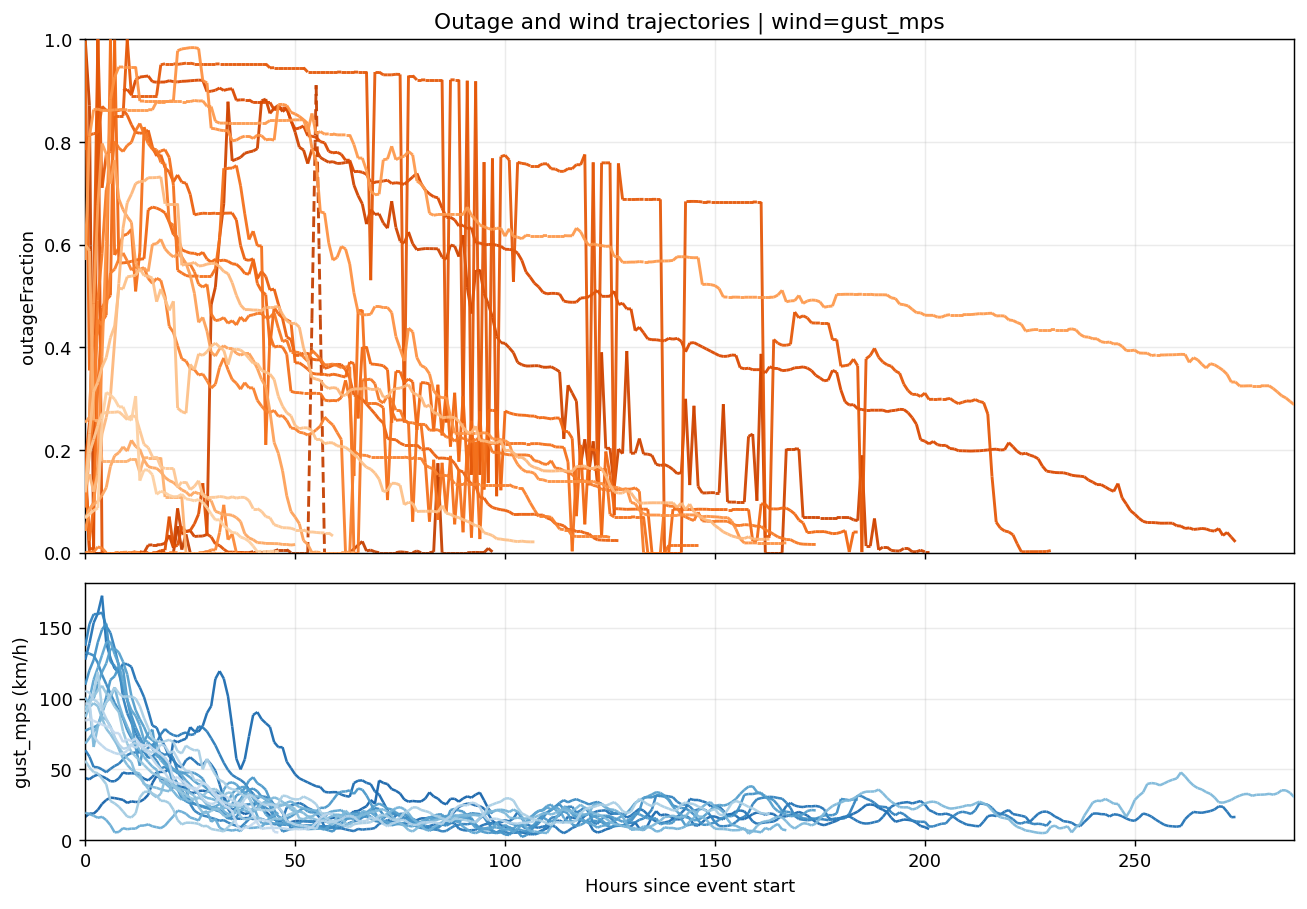

In [32]:
# Cell 7: outage + wind panel
fig, meta = plot_overlay(
    df,
    value_col="outageFraction",
    wind_kind=WIND_KIND,             # "gust_mps" or "wind_speed_mps"
    threshold_pct=COVERAGE_THRESHOLD_PCT,
    interpolate_missing=USE_INTERPOLATION,
    smooth_window=SMOOTH_WINDOW,
    max_windows=MAX_WINDOWS_TO_PLOT,
    title=f"Outage and wind trajectories | wind={WIND_KIND}",
    outfile=BASE / "outage_wind_overlay.png",
)
plt.show()

In [21]:
# Cell 8: animated GIF with accumulating history, dynamic title, and storm-name lookup

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from PIL import Image

IBTRACS_TXT = Path(r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\ibtracs.txt")

def load_storm_name_lookup(txt_path):
    """
    Parse a small IBTrACS-style text file and build SID -> storm name.
    Prefers the first meaningful non-NOT_NAMED entry seen for each SID.
    """
    lookup = {}

    with open(txt_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            parts = line.strip().split(None, 2)
            if len(parts) < 3:
                continue

            sid = parts[0].strip()
            name_blob = parts[2].strip()

            # Take the token before any bracket metadata or appended notes.
            name = name_blob.split("[", 1)[0].strip()
            if not name:
                continue

            name_upper = name.upper()
            if name_upper in {"NONE", "NOT_NAMED", "NOT NAMED", "MULTIPLE"}:
                continue

            # Keep the first meaningful name found for each SID.
            if sid not in lookup:
                lookup[sid] = name_upper

    return lookup

def pretty_storm_name(storm_lookup, sid):
    sid = str(sid)
    raw = storm_lookup.get(sid, sid)
    if raw.upper() in {"NONE", "NOT_NAMED", "NOT NAMED", "MULTIPLE"}:
        return sid
    return raw.title()

storm_lookup = load_storm_name_lookup(IBTRACS_TXT)

def build_gif(
    df,
    value_col="outageFraction",
    wind_kind=None,  # None, "gust_mps", or "wind_speed_mps"
    threshold_pct=COVERAGE_THRESHOLD_PCT,
    interpolate_missing=False,
    smooth_window=None,
    max_windows=MAX_WINDOWS_TO_PLOT,
    x_cap_hours=MAX_X_HOURS_CAP,
    hour_step=ANIM_HOUR_STEP,
    interval_ms=ANIM_INTERVAL_MS,
    outfile=BASE / "trajectory_build.gif",
    colors=96,
):
    sub, meta = choose_windows(df, max_windows=max_windows)

    # Attach readable storm names for the title block.
    meta = meta.copy()
    meta["storm_name"] = meta["storm"].map(lambda s: pretty_storm_name(storm_lookup, s))

    longest = int(sub.groupby("window_id")["rel_hour"].max().max())
    x_max = min(longest, x_cap_hours)

    outage_cmap = mpl.cm.Oranges
    wind_cmap = mpl.cm.Blues
    grey_cmap = mpl.cm.Greys

    out_series = []
    wind_series = []

    for wid, g in sub.groupby("window_id", sort=False):
        s = make_hourly_series(
            g,
            value_col=value_col,
            threshold_pct=threshold_pct,
            interpolate_missing=interpolate_missing,
            smooth_window=smooth_window,
            x_cap_hours=x_max,
            convert_to_kmh=False,
        )
        s["window_id"] = wid
        s["window_rank"] = g["window_rank"].iloc[0]
        out_series.append(s)

        if wind_kind is not None and wind_kind in g.columns:
            w = make_hourly_series(
                g,
                value_col=wind_kind,
                threshold_pct=None,
                interpolate_missing=interpolate_missing,
                smooth_window=smooth_window,
                x_cap_hours=x_max,
                convert_to_kmh=True,
            )
            w["window_id"] = wid
            w["window_rank"] = g["window_rank"].iloc[0]
            wind_series.append(w)

    out_series = sorted(out_series, key=lambda d: d["window_rank"].iloc[0])
    wind_series = sorted(wind_series, key=lambda d: d["window_rank"].iloc[0]) if wind_series else []

    fig, ax = plt.subplots(
        2 if wind_kind is not None and wind_series else 1,
        1,
        figsize=(12, 8 if (wind_kind is not None and wind_series) else 5.5),
        sharex=True,
        gridspec_kw={"height_ratios": [2, 1], "hspace": 0.08} if (wind_kind is not None and wind_series) else None,
    )

    if not isinstance(ax, np.ndarray):
        ax = np.array([ax])

    # Precompute grey shades: earlier windows lighter, later windows darker.
    n_out = len(out_series)
    grey_levels_out = np.linspace(0.88, 0.30, n_out) if n_out > 1 else np.array([0.55])

    n_wind = len(wind_series)
    grey_levels_wind = np.linspace(0.88, 0.30, n_wind) if n_wind > 1 else np.array([0.55])

    # Build frame schedule: event 1 grows, then event 2, etc.
    frames = []
    for i, s in enumerate(out_series):
        final_h = int(s["hour"].max())
        event_hours = list(range(0, final_h + 1, hour_step))
        if event_hours[-1] != final_h:
            event_hours.append(final_h)
        for h in event_hours:
            frames.append((i, h))

    def draw_panel(ax_, series_list, active_idx, hour, active_color, ylabel, ylimit=None, grey_levels=None):
        ax_.clear()
        ax_.set_xlim(0, x_max)
        ax_.grid(True, alpha=0.25)
        ax_.set_ylabel(ylabel)

        # Draw completed previous windows in greys.
        for j in range(active_idx):
            s = series_list[j]
            color = grey_cmap(grey_levels[j])
            add_piecewise_line(
                ax_,
                s["hour"].to_numpy(),
                s["value"].to_numpy(),
                s["interpolated"].to_numpy(),
                color=color,
                lw=1.15,
                alpha=0.95,
                zorder=1 + j,
            )

        # Draw the active window up to the current hour in color.
        if active_idx is not None and 0 <= active_idx < len(series_list):
            s = series_list[active_idx]
            active_sub = s[s["hour"] <= hour].copy()
            add_piecewise_line(
                ax_,
                active_sub["hour"].to_numpy(),
                active_sub["value"].to_numpy(),
                active_sub["interpolated"].to_numpy(),
                color=active_color,
                lw=1.85,
                alpha=1.0,
                zorder=100,
            )

        if ylimit is not None:
            ax_.set_ylim(*ylimit)

    wind_max = 0.0
    for s in wind_series:
        vals = s["value"].dropna()
        if len(vals):
            wind_max = max(wind_max, float(vals.max()))
    wind_ylim = (0, wind_max * 1.05 if wind_max > 0 else 1.0)

    def update(frame):
        event_idx, hour = frame

        # Active window metadata for the title block.
        row = meta.iloc[event_idx]
        storm_name = row["storm_name"]
        county = row["county"] if "county" in row and pd.notna(row["county"]) else ""
        fips = row["CountyFIPS"] if "CountyFIPS" in row and pd.notna(row["CountyFIPS"]) else ""
        title = f"Storm: {storm_name} | County: {county} | FIPS: {fips}\nWindow {event_idx + 1}/{len(out_series)} | hour {hour}"
        fig.suptitle(title, y=0.98, fontsize=12)

        # Outage panel
        draw_panel(
            ax[0],
            out_series,
            event_idx,
            hour,
            active_color=outage_cmap(0.55),
            ylabel="outageFraction",
            ylimit=(0, 1.0),
            grey_levels=grey_levels_out,
        )

        # Optional wind panel
        if wind_kind is not None and wind_series and len(ax) > 1:
            draw_panel(
                ax[1],
                wind_series,
                event_idx if event_idx < len(wind_series) else None,
                hour,
                active_color=wind_cmap(0.55),
                ylabel=f"{wind_kind} (km/h)",
                ylimit=wind_ylim,
                grey_levels=grey_levels_wind,
            )
            ax[1].set_xlabel("Hours since event start")
        else:
            ax[0].set_xlabel("Hours since event start")

        return fig.axes

    # Render frames to PIL images and write GIF directly.
    pil_frames = []
    for frame in frames:
        update(frame)
        fig.canvas.draw()
        rgba = np.asarray(fig.canvas.buffer_rgba())
        img = Image.fromarray(rgba).convert("RGB")
        img = img.quantize(colors=colors)
        pil_frames.append(img)

    pil_frames[0].save(
        outfile,
        save_all=True,
        append_images=pil_frames[1:],
        duration=interval_ms,
        loop=0,
        optimize=False,
    )

    plt.close(fig)
    return outfile

# Example call:
gif_path = build_gif(
    df,
    value_col="outageFraction",
    wind_kind=WIND_KIND,  # set to "gust_mps", "wind_speed_mps", or None
    threshold_pct=COVERAGE_THRESHOLD_PCT,
    interpolate_missing=USE_INTERPOLATION,
    smooth_window=SMOOTH_WINDOW,
    max_windows=MAX_WINDOWS_TO_PLOT,
    outfile=BASE / "trajectory_build.gif",
)
print(gif_path)

C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\trajectory_build.gif


In [22]:
# test to see if txt file lookup is working for storm name
path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\ibtracs.txt"  # adjust if needed

rows = []
with open(path, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 3:
            sid = parts[0]
            name_raw = parts[2]

            # clean name (remove bracket metadata)
            name = name_raw.split("[")[0]

            rows.append((sid, name))

lookup = pd.DataFrame(rows, columns=["SID", "NAME"])

# remove duplicates, keep first occurrence
lookup = lookup.drop_duplicates("SID").set_index("SID")

# test your example
test_id = "2017212N28275"
print("Lookup result:", lookup.get("NAME").get(test_id, "NOT FOUND"))

Lookup result: EMILY
